Cloning into 'GreenPulse'...
remote: Enumerating objects: 75, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (62/62), done.
remote: Total 75 (delta 28), reused 26 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (75/75), 15.51 MiB | 34.68 MiB/s, done.
Resolving deltas: 100% (28/28), done.
/content/GreenPulse
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 534M/534M [00:08<00:00, 67.4MB/s]

Extracting files...


/kaggle/input/plantvillage-dataset
/root/.cache/kagglehub/datasets/karagwaanntreasure/plant-disease-detection/versions/1
Class mapping defined for 7 unified target classes
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.


100%|██████████| 1.01G/1.01G [00:08<00:00, 125MB/s]

Extracting files...


Cleaned dataset! Removed 5484 duplicate images.

Clean Unified Dataset Structure:
  └─ Tomato_Late_Blight: 1901 unique images
  └─ Cocoa_Pod_Borer: 103 unique images
  └─ Maize_Common_Rust: 2144 unique images
  └─ Tomato_Early_Blight: 1000 unique images
  └─ Maize_Northern_Leaf_Blight: 2116 unique images
  └─ Tomato_Leaf_Mold: 952 unique images
  └─ Cocoa_Healthy: 3344 unique images
  └─ Cocoa_Black_Pod_Rot: 943 unique images
  └─ Maize_Healthy: 2084 unique images
  └─ Tomato_Healthy: 1585 unique images


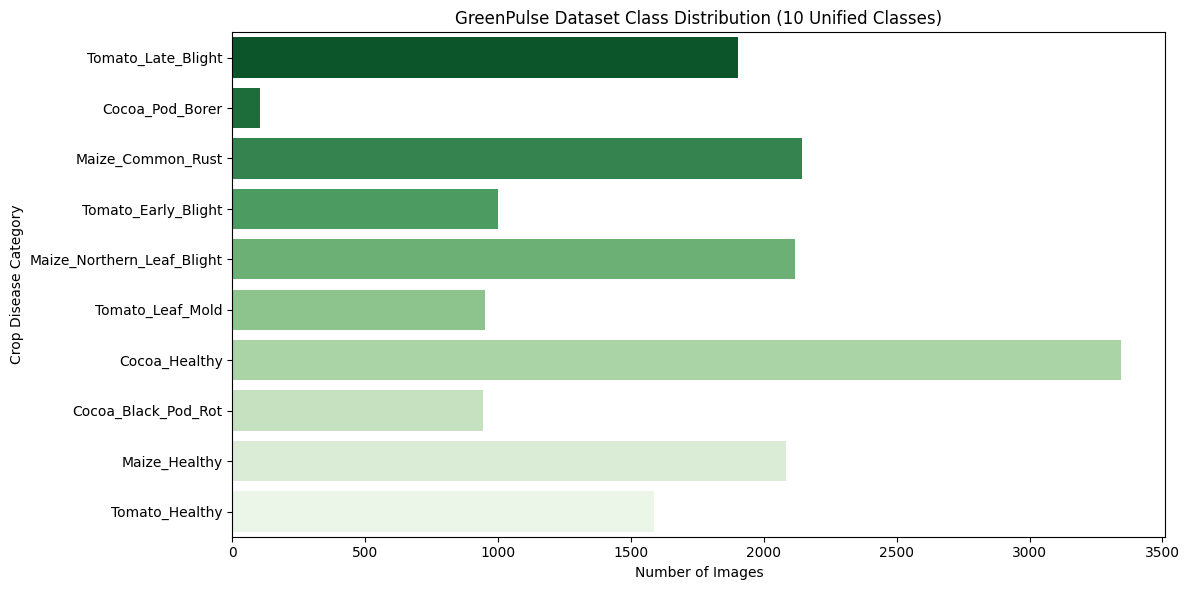

In [1]:
!git clone https://github.com/KekeliIsHere/GreenPulse.git
%cd GreenPulse
%run notebooks/00_data_exploration_and_cleaning.ipynb

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [3]:
from pathlib import Path

dataset_path = Path("/content/clean_crop_dataset")
print(dataset_path.exists())

True


In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split, DataLoader, Subset

from torchvision.models import mobilenet_v3_large
from torchvision.models import MobileNet_V3_Large_Weights

torch.manual_seed(0)
np.random.seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Using device: cuda
GPU: Tesla T4


In [5]:
full_dataset = ImageFolder(
    root=dataset_path
)

print(full_dataset.classes)
print(len(full_dataset))

['Cocoa_Black_Pod_Rot', 'Cocoa_Healthy', 'Cocoa_Pod_Borer', 'Maize_Common_Rust', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold']
16172


In [6]:
# Augmentating the images to let the model learn from  different versions of
# the same image across epochs.
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
# Transform the test data
test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
total_size = len(full_dataset)

train_size = int(0.70 * total_size)

val_size = int(0.15 * total_size)

test_size = (
    total_size
    - train_size
    - val_size
)

print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Train: 11320
Validation: 2425
Test: 2427


In [9]:
generator = torch.Generator().manual_seed(42)

indices = torch.randperm(
    total_size,
    generator=generator
).tolist()

In [10]:
train_indices = indices[:train_size]

val_indices = indices[
    train_size:
    train_size + val_size
]

test_indices = indices[
    train_size + val_size:
]

In [11]:
train_dataset = ImageFolder(
    root=dataset_path,
    transform=train_transform
)

val_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)

test_dataset = ImageFolder(
    root=dataset_path,
    transform=test_transform
)



In [12]:

train_ds = Subset(
    train_dataset,
    train_indices
)

val_ds = Subset(
    val_dataset,
    val_indices
)

test_ds = Subset(
    test_dataset,
    test_indices
)

In [13]:
# creating the dataloaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [14]:
print("Training images:", len(train_ds))
print("Validation images:", len(val_ds))
print("Test images:", len(test_ds))

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training images: 11320
Validation images: 2425
Test images: 2427
Training batches: 354
Validation batches: 76
Test batches: 76


In [15]:
# Checking training batch before training
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


torch.Size([32, 3, 224, 224])
torch.Size([32])


In [16]:
# Loading the pretrained model
weights = MobileNet_V3_Large_Weights.DEFAULT
model = mobilenet_v3_large(weights=weights)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 148MB/s]


In [17]:
# the NUM_CLASSES would form the output classes for classification
NUM_CLASSES = len(full_dataset.classes)

model.classifier[3] = nn.Linear(

    model.classifier[3].in_features,

    NUM_CLASSES

)

In [18]:
# Freezing the earlier layers and only keeping the classifier which would be trained on
# the disease detection
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

In [19]:
print("Trainable parameters:")
for name, param in model.named_parameters():
  if param.requires_grad:
    print(f" {name}")

Trainable parameters:
 classifier.0.weight
 classifier.0.bias
 classifier.3.weight
 classifier.3.bias


In [20]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds.cpu())
        all_labels.append(labels.cpu())

    avg_loss = running_loss / total
    accuracy = correct / total
    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return avg_loss, accuracy, preds, labels

In [21]:
def fit(model, epochs=5, lr=1e-4):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(f"Epoch {epoch:2d}/{epochs} | "
              f"train loss {tr_loss:.3f} acc {tr_acc:.3f} | "
              f"val loss {va_loss:.3f} acc {va_acc:.3f}")
    return history

In [22]:
history = fit(
    model,
    epochs=5,
    lr=1e-4
)


Epoch  1/5 | train loss 0.675 acc 0.837 | val loss 0.258 acc 0.926
Epoch  2/5 | train loss 0.230 acc 0.932 | val loss 0.176 acc 0.945
Epoch  3/5 | train loss 0.176 acc 0.944 | val loss 0.152 acc 0.952
Epoch  4/5 | train loss 0.150 acc 0.948 | val loss 0.145 acc 0.953
Epoch  5/5 | train loss 0.135 acc 0.955 | val loss 0.137 acc 0.953


In [23]:
print(history)

{'train_loss': [0.6751507770256946, 0.22981575283060646, 0.17558559726910541, 0.15012383614749034, 0.13499771614588613], 'train_acc': [0.8368374558303887, 0.9324204946996466, 0.9440812720848056, 0.948321554770318, 0.9546819787985866], 'val_loss': [0.25821646553339417, 0.1760954371893529, 0.1522813399520117, 0.14513828057142877, 0.13733614457636764], 'val_acc': [0.9257731958762887, 0.9451546391752578, 0.9521649484536082, 0.9529896907216495, 0.9529896907216495]}


In [24]:
torch.save(
    model.state_dict(),
    "crop_disease_model.pth"
)

In [25]:
import os

print(os.path.exists("crop_disease_model.pth"))
print(f"Model size: {os.path.getsize('crop_disease_model.pth') / (1024**2):.2f} MB")

True
Model size: 16.28 MB


In [26]:
from google.colab import files

files.download("crop_disease_model.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>